In [3]:
# %matplotlib inline
import json
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_squared_error, r2_score

# Dynamically resolve the data directory whether running from root or notebooks/
current_dir = Path.cwd()
if current_dir.name == "notebooks":
    DATA_ROOT = current_dir.parent / "data"
else:
    DATA_ROOT = current_dir / "scripts" / "statistical_analysis" / "data"

CSV_FILE = DATA_ROOT / "dataset_summary.csv"

print(f"Data directory set to: {DATA_ROOT}")

Data directory set to: /Users/neerajkaroshi/Desktop/Projects/chmv2_pipeline/scripts/statistical_analysis/data


Total Plots Analyzed : 100
Root Mean Sq Error   : 8.08 meters
Mean Bias Error      : 1.49 meters
Pearson R-squared    : -7.14


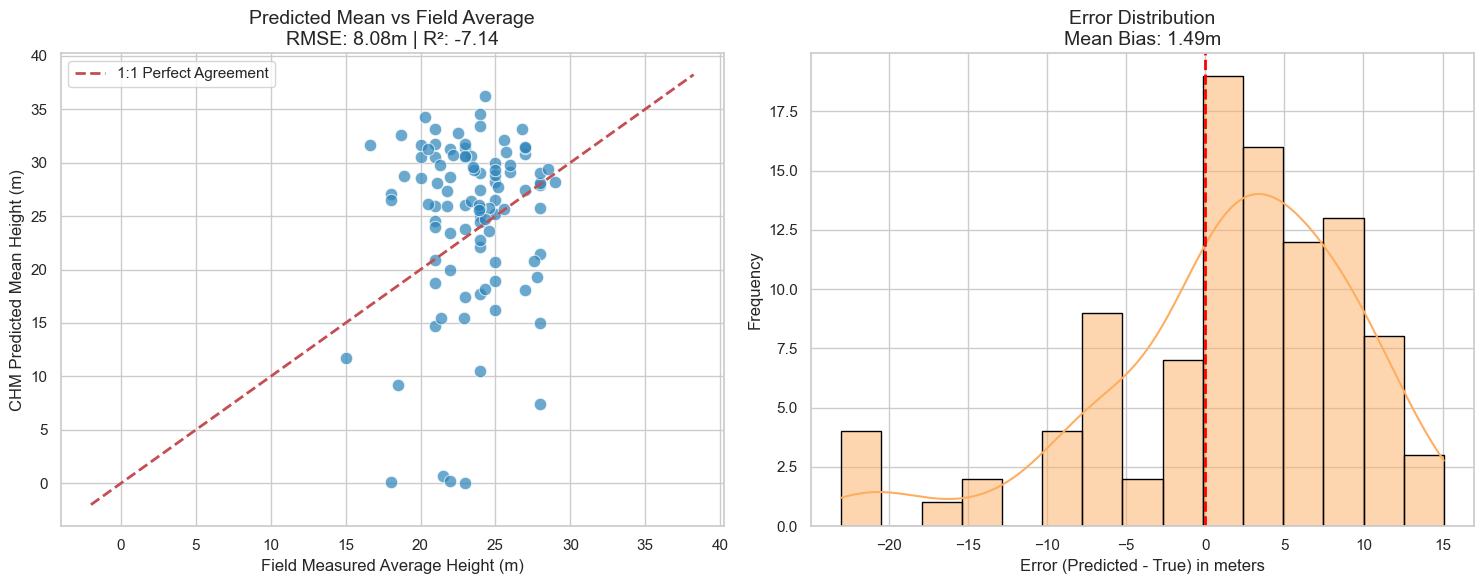

In [4]:
# Load the summary dataset
if not CSV_FILE.exists():
    print(f"Error: Could not find {CSV_FILE}. Run the extraction script first.")
else:
    df = pd.read_csv(CSV_FILE)
    df = df.dropna(subset=['h_avg_field', 'h_pred_mean'])
    
    y_true = df['h_avg_field']
    y_pred = df['h_pred_mean']
    
    # Calculate error metrics
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    bias = np.mean(y_pred - y_true)
    r2 = r2_score(y_true, y_pred)
    
    print(f"Total Plots Analyzed : {len(df)}")
    print(f"Root Mean Sq Error   : {rmse:.2f} meters")
    print(f"Mean Bias Error      : {bias:.2f} meters")
    print(f"Pearson R-squared    : {r2:.2f}")

    # Set up the visualization
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    
    # 1. Scatter Plot (Predicted vs True)
    sns.scatterplot(x=y_true, y=y_pred, ax=axes[0], s=80, alpha=0.7, color='#2b83ba')
    
    # Add 1:1 reference line
    min_val = min(y_true.min(), y_pred.min()) - 2
    max_val = max(y_true.max(), y_pred.max()) + 2
    axes[0].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='1:1 Perfect Agreement')
    
    axes[0].set_title(f'Predicted Mean vs Field Average\nRMSE: {rmse:.2f}m | R²: {r2:.2f}', fontsize=14)
    axes[0].set_xlabel('Field Measured Average Height (m)', fontsize=12)
    axes[0].set_ylabel('CHM Predicted Mean Height (m)', fontsize=12)
    axes[0].legend()

    # 2. Residual Error Distribution
    errors = y_pred - y_true
    sns.histplot(errors, bins=15, kde=True, ax=axes[1], color='#fdae61', edgecolor='black')
    axes[1].axvline(0, color='red', linestyle='--', linewidth=2)
    
    axes[1].set_title(f'Error Distribution\nMean Bias: {bias:.2f}m', fontsize=14)
    axes[1].set_xlabel('Error (Predicted - True) in meters', fontsize=12)
    axes[1].set_ylabel('Frequency', fontsize=12)
    
    plt.tight_layout()
    plt.show()

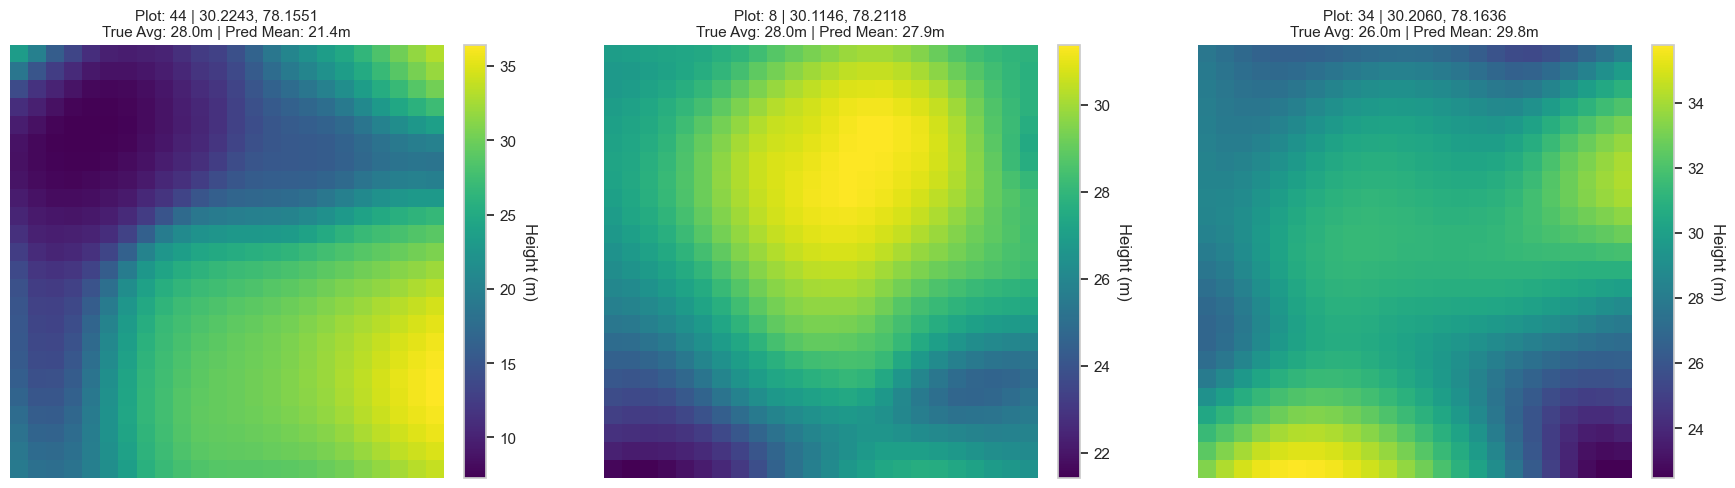

In [5]:
# Number of random plots to visualize
NUM_SAMPLES = 3

plot_dirs = [d for d in DATA_ROOT.iterdir() if d.is_dir() and d.name.startswith("plot_")]

if not plot_dirs:
    print("No individual plot directories found.")
else:
    samples = random.sample(plot_dirs, min(NUM_SAMPLES, len(plot_dirs)))
    
    fig, axes = plt.subplots(1, len(samples), figsize=(6 * len(samples), 5))
    if len(samples) == 1:
        axes = [axes]
        
    for i, pdir in enumerate(samples):
        npy_path = pdir / "pixels.npy"
        meta_path = pdir / "metadata.json"
        
        if not npy_path.exists() or not meta_path.exists():
            print(f"Missing data in {pdir.name}")
            continue
            
        # Load the 2D pixel array and metadata
        pixels = np.load(npy_path)
        with open(meta_path, 'r') as f:
            meta = json.load(f)
            
        h_true = meta['h_avg_field']
        h_pred = meta['h_pred_mean']
        
        # Render the canopy heatmap
        ax = axes[i]
        im = ax.imshow(pixels, cmap='viridis')
        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Height (m)', rotation=270, labelpad=15)
        
        ax.set_title(f"Plot: {meta['sr']} | {meta['lat']:.4f}, {meta['lon']:.4f}\nTrue Avg: {h_true}m | Pred Mean: {h_pred:.1f}m", fontsize=11)
        ax.axis('off') 
        
    plt.tight_layout()
    plt.show()

/Users/neerajkaroshi/Desktop/Projects/chmv2_pipeline


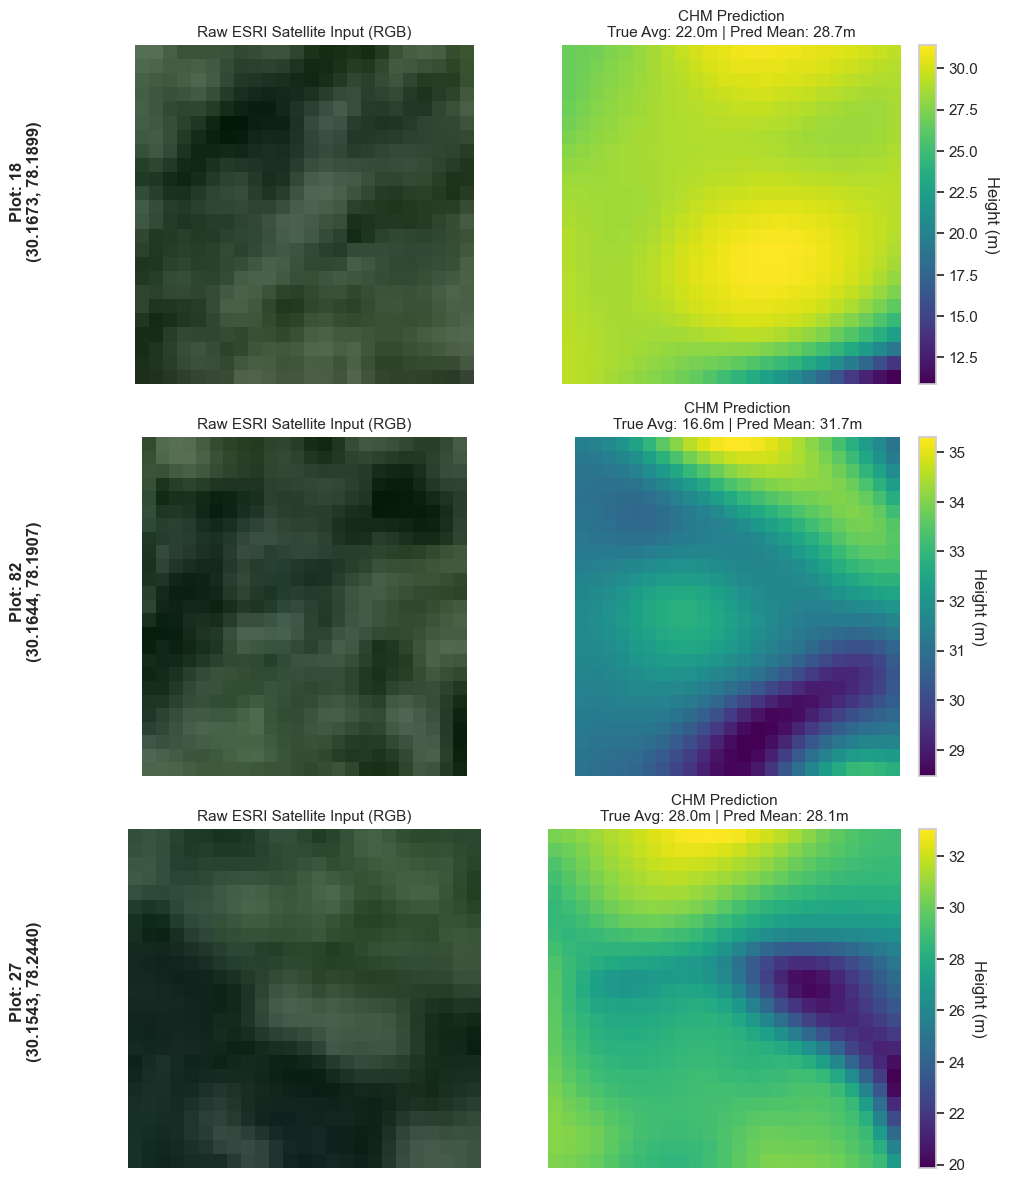

In [19]:
import json
import random
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

# Number of random plots to visualize
NUM_SAMPLES = 3

# Safely resolve the repository root directory

repo_root = current_dir.parent.parent.parent
print(repo_root)
# Define exact data paths using pathlib
DATA_ROOT = repo_root / "scripts" / "statistical_analysis" / "data"
ESRI_ROOT = repo_root / "data" / "input" / "esri_patches"

plot_dirs = [d for d in DATA_ROOT.iterdir() if d.is_dir() and d.name.startswith("plot_")]

if not plot_dirs:
    print(f"No individual plot directories found in {DATA_ROOT}")
else:
    samples = random.sample(plot_dirs, min(NUM_SAMPLES, len(plot_dirs)))
    
    # Create a grid: NUM_SAMPLES rows, 2 columns (Raw RGB, CHM Heatmap)
    fig, axes = plt.subplots(len(samples), 2, figsize=(10, 4 * len(samples)))
    
    # Handle case where there's only 1 sample (axes becomes 1D)
    if len(samples) == 1:
        axes = np.expand_dims(axes, axis=0)
        
    for i, pdir in enumerate(samples):
        npy_path = pdir / "pixels.npy"
        meta_path = pdir / "metadata.json"
        
        if not npy_path.exists() or not meta_path.exists():
            print(f"Missing data in {pdir.name}")
            continue
            
        # Load the CHM pixel array and metadata
        pixels = np.load(npy_path)
        with open(meta_path, 'r') as f:
            meta = json.load(f)
            
        h_true = meta['h_avg_field']
        h_pred = meta['h_pred_mean']
        tile_key = meta['tile_key']
        bbox = meta['bbox']
        
        # -----------------------------------------------------------
        # Column 1: Raw ESRI Optical Pixels
        # -----------------------------------------------------------
        ax_raw = axes[i, 0]
        
        # Construct the exact path to the PNG
        esri_path = ESRI_ROOT / f"esri_512_{tile_key}.png"
        
        if esri_path.exists():
            with Image.open(esri_path) as img:
                # Crop using the exact bounding box from metadata
                raw_crop = img.crop((bbox['col_min'], bbox['row_min'], bbox['col_max'], bbox['row_max']))
                ax_raw.imshow(raw_crop)
                ax_raw.set_title("Raw ESRI Satellite Input (RGB)", fontsize=11)
        else:
            ax_raw.text(0.5, 0.5, f"Raw Image Not Found\n{esri_path.name}", ha='center', va='center')
        
        ax_raw.axis('off')
        
        # -----------------------------------------------------------
        # Column 2: Predicted CHM Heatmap
        # -----------------------------------------------------------
        ax_chm = axes[i, 1]
        im = ax_chm.imshow(pixels, cmap='viridis')
        cbar = plt.colorbar(im, ax=ax_chm, fraction=0.046, pad=0.04)
        cbar.set_label('Height (m)', rotation=270, labelpad=15)
        
        ax_chm.set_title(f"CHM Prediction\nTrue Avg: {h_true}m | Pred Mean: {h_pred:.1f}m", fontsize=11)
        ax_chm.axis('off') 
        
        # Add Plot ID label to the far left of the row
        fig.text(0.02, 1 - (i + 0.5)/len(samples), 
                 f"Plot: {meta['sr']}\n({meta['lat']:.4f}, {meta['lon']:.4f})", 
                 va='center', ha='center', rotation=90, fontsize=12, fontweight='bold')
        
    # Adjust layout to leave room for the left labels
    plt.tight_layout(rect=[0.05, 0, 1, 1])
    plt.show()

In [24]:
# 1. Resolve the repository root (3 directories back as specified)
current_dir = Path.cwd()
repo_root = current_dir.parent.parent.parent



# 2. Define exact data paths using the resolved repo_root
DATA_ROOT = repo_root / "scripts" / "statistical_analysis" / "data"
ESRI_ROOT = repo_root / "data" / "input" / "esri_patches"
CSV_FILE = repo_root /  "scripts" / "statistical_analysis" / "dataset_summary.csv"



# 3. Load and process the dataframe
if not CSV_FILE.exists():
    print(f"File not found: {CSV_FILE}")
    print("Please ensure the extraction script has been run and the path is correct.")
else:
    # Load the dataframe
    df = pd.read_csv(CSV_FILE)
    
    # Drop any plots that failed to extract properly (missing values)
    df = df.dropna(subset=['h_avg_field', 'h_pred_mean']).copy()
    
    # Calculate the error metrics for each row
    # Error = Predicted - True (Positive means model overestimated, Negative means underestimated)
    df['Error'] = (df['h_pred_mean'] - df['h_avg_field']).round(2)
    df['Abs_Error'] = df['Error'].abs()
    
    # Select the most important columns to view
    display_cols = [
        'sr',             # Plot ID
        'h_avg_field',    # True Field Average (m)
        'h_pred_mean',    # Predicted CHM Mean (m)
        'Error',          # Deviation (Predicted - True)
        'Abs_Error',      # Absolute Error for sorting
        'h_pred_median',  # Predicted CHM Median
        'h_pred_std',     # Variation within the plot
        'n_pixels',       # Number of valid pixels used for the average
        'coverage_ratio'  # How much of the 12.5x12.5m box was valid
    ]
    
    # Filter to only requested columns that exist in the dataframe
    available_cols = [c for c in display_cols if c in df.columns]
    view_df = df[available_cols].copy()
    
    # Sort by Absolute Error to see where the model is most accurate first
    if 'Abs_Error' in view_df.columns:
        view_df = view_df.sort_values(by='Abs_Error', ascending=True)
    
    # Reset index for cleaner display
    view_df = view_df.reset_index(drop=True)
    
    print(f"Successfully loaded data for {len(view_df)} plots.\n")
    
    # Display the top 20 rows
    # Note: If running in a Jupyter Notebook, `display()` provides a nicely formatted HTML table.
    try:
        display(view_df.head(20))
    except NameError:
        # Fallback if running as a standard Python script in the terminal
        print(view_df.head(20).to_string())

Successfully loaded data for 100 plots.



,sr,h_avg_field,h_pred_mean,Error,Abs_Error,h_pred_median,h_pred_std,n_pixels,coverage_ratio
0,8,28.0,27.945749,-0.05,0.05,28.072435,2.254351,576,1.0
1,98,25.6,25.664785,0.06,0.06,26.228899,6.236966,576,1.0
2,90,21.0,20.914116,-0.09,0.09,23.479092,6.844951,576,1.0
3,27,28.0,28.115072,0.12,0.12,28.779491,2.714686,600,1.0
4,53,25.0,25.179544,0.18,0.18,26.376831,4.783776,576,1.0
5,40,27.0,27.451324,0.45,0.45,28.343105,4.932086,625,1.0
6,75,24.3,24.764730,0.46,0.46,25.718906,2.186580,528,1.0
7,60,24.0,24.476799,0.48,0.48,25.694767,4.614814,576,1.0
8,15,23.0,23.775597,0.78,0.78,24.630856,3.861097,600,1.0
9,39,29.0,28.209652,-0.79,0.79,28.764433,2.674011,576,1.0


In [25]:
df.head()

,sr,lat,lon,h_avg_field,h_pred_mean,h_pred_std,h_pred_min,h_pred_max,h_pred_median,n_pixels,coverage_ratio,tile_key,Error,Abs_Error
0,1,30.12714,78.25838,21.0,24.499262,2.599924,17.942537,28.829847,25.159393,360,1.0,z18_188058_108047,3.50,3.50
1,2,30.12591,78.25545,23.0,26.010990,4.510683,12.532547,31.474602,27.618654,576,1.0,z18_188055_108048,3.01,3.01
2,3,30.12571,78.25219,25.0,20.745291,5.028338,9.861094,29.927973,20.703838,576,1.0,z18_188053_108048,-4.25,4.25
3,4,30.12482,78.24848,18.9,28.757467,3.889994,22.155682,34.873505,28.836853,576,1.0,z18_188050_108049,9.86,9.86
4,5,30.12400,78.24399,22.9,15.444948,5.060161,7.229948,26.318604,14.754275,576,1.0,z18_188047_108049,-7.46,7.46


In [ ]:
df.describe("errors")

,sr,lat,lon,h_avg_field,h_pred_mean,h_pred_std,h_pred_min,h_pred_max,h_pred_median,n_pixels,coverage_ratio,Error,Abs_Error
count,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.0,100.000000,100.000000
mean,50.500000,30.149293,78.211126,23.441000,24.933210,3.933238,15.756540,31.583669,25.280687,568.020000,1.0,1.492600,6.339600
std,29.011492,0.048588,0.031590,2.848395,7.745077,2.281173,8.243645,7.606209,8.126430,57.236172,0.0,7.984876,5.041043
min,1.000000,30.087740,78.151560,15.000000,0.013797,0.003919,0.010483,0.029624,0.011972,312.000000,1.0,-22.990000,0.050000
25%,25.750000,30.113923,78.188120,21.375000,21.962568,2.393180,10.111027,30.361483,22.761500,576.000000,1.0,-1.905000,2.265000
50%,50.500000,30.129170,78.211570,23.900000,26.819621,3.472274,16.737852,33.139076,27.439062,576.000000,1.0,2.960000,5.645000
75%,75.250000,30.170430,78.235065,25.000000,30.479567,4.889684,22.028335,35.218224,31.131886,600.000000,1.0,7.010000,8.832500
max,100.000000,30.252340,78.276880,29.000000,36.220486,11.100377,30.345047,42.655716,36.581631,625.000000,1.0,15.080000,22.990000


             CHMv2 STATISTICAL EVALUATION             
Sample Size (N)        : 100 plots
Root Mean Square Error : 8.083 m
Mean Absolute Error    : 6.339 m
Mean Bias Error        : 1.492 m
Coefficient of Det (R²): -7.135
Pearson Correlation (r): 0.099 (p-value: 3.3e-01)

--- Error by Height Class (Saturation Check) ---


,Num Plots,Mean Bias (m),Std Dev (m)
Height_Class,,,
< 20m,11,5.17,10.56
20 - 24m,52,2.15,8.24
24 - 27m,26,1.42,4.93
> 27m,11,-5.14,6.86




--- Top 5 Worst Performing Plots (Outliers) ---


,sr,h_avg_field,h_pred_mean,Error,h_pred_std
40,41,23.0,0.013797,-22.986203,0.003919
93,94,22.0,0.200178,-21.799822,0.163684
91,92,21.5,0.698874,-20.801126,0.613552
5,6,28.0,7.460426,-20.539574,10.617382
41,42,18.0,0.121172,-17.878828,0.272323


/var/folders/nw/whndd4zx0yq8ggmr1g5hhd5m0000gn/T/ipykernel_55644/3252211139.py:96: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Height_Class', y='Error', data=df, ax=axes[1, 1], palette='Set2')



Saved diagnostic plots to: /Users/neerajkaroshi/Desktop/Projects/chmv2_pipeline/scripts/statistical_analysis/data/statistical_diagnostics.png


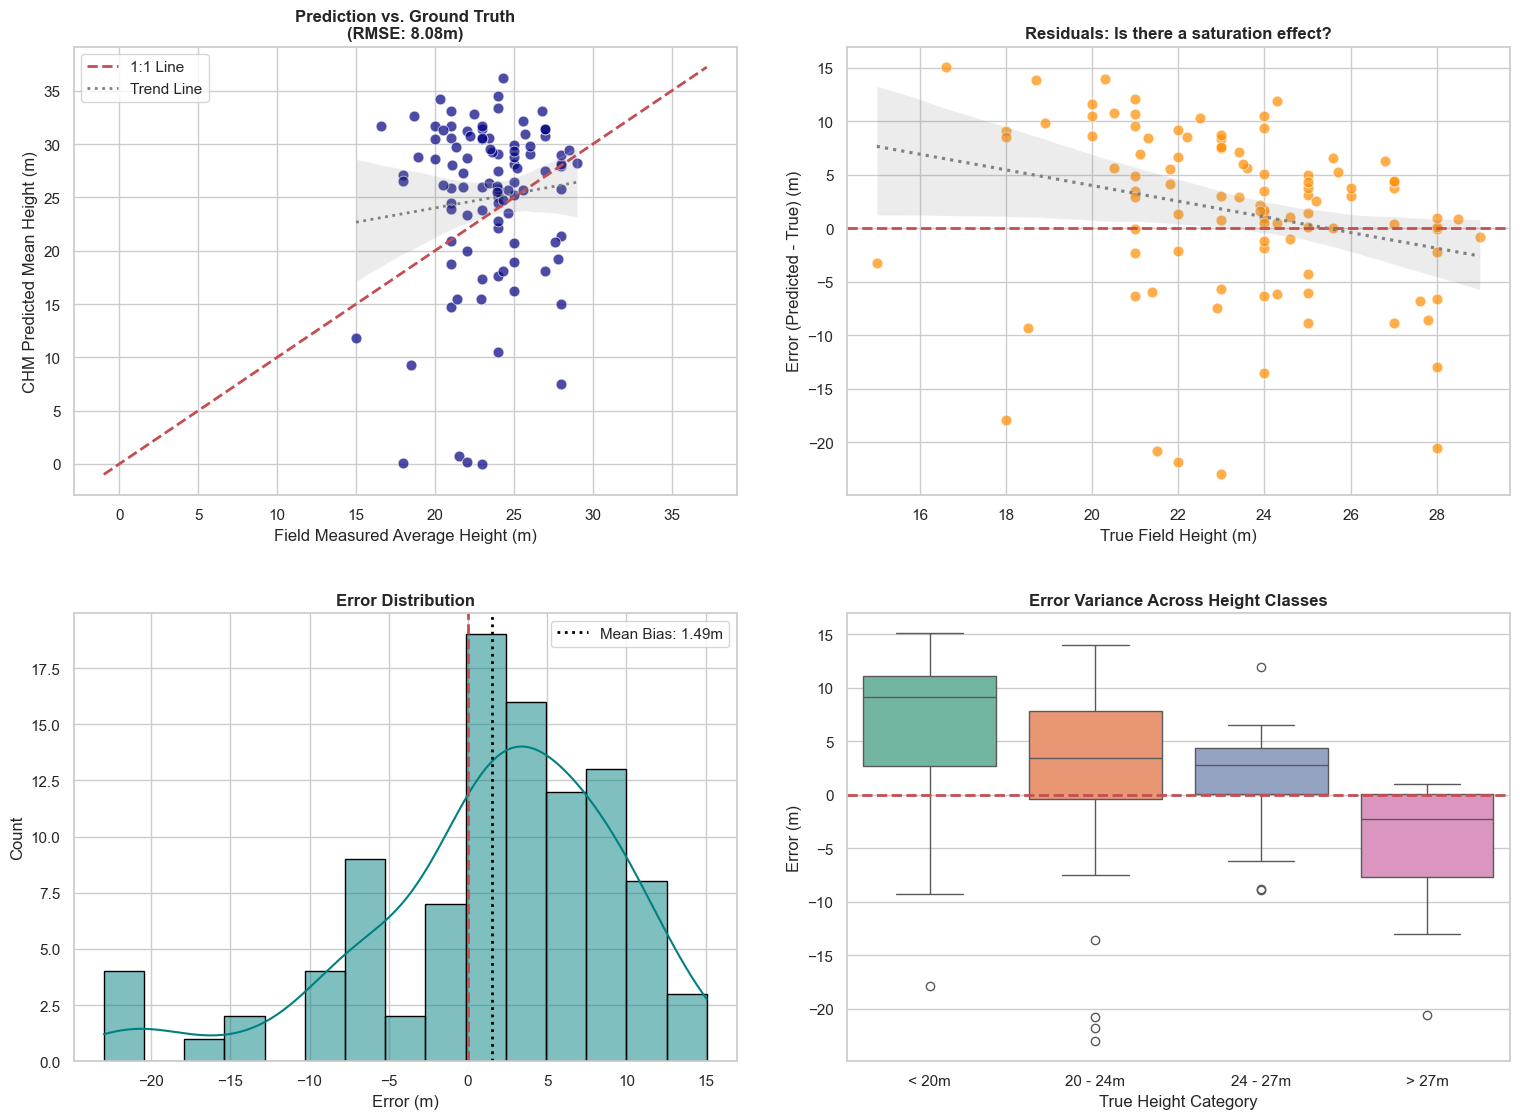

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from pathlib import Path

# --- 1. Path Resolution ---
current_dir = Path.cwd()
# Adjust this based on where your notebook is running (using your previous structure)
repo_root = current_dir.parent.parent.parent 
CSV_FILE = repo_root / "scripts" / "statistical_analysis" / "dataset_summary.csv"

if not CSV_FILE.exists():
    print(f"Cannot find data at: {CSV_FILE}")
else:
    # --- 2. Data Loading & Cleaning ---
    df = pd.read_csv(CSV_FILE)
    df = df.dropna(subset=['h_avg_field', 'h_pred_mean']).copy()
    
    y_true = df['h_avg_field']
    y_pred = df['h_pred_mean']
    
    # Calculate Error (Positive = Model Overestimated, Negative = Model Underestimated)
    df['Error'] = df['h_pred_mean'] - df['h_avg_field']
    df['Abs_Error'] = df['Error'].abs()

    # --- 3. Global Statistical Metrics ---
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    bias = np.mean(df['Error'])
    r2 = r2_score(y_true, y_pred)
    pearson_r, p_value = stats.pearsonr(y_true, y_pred)

    print("======================================================")
    print("             CHMv2 STATISTICAL EVALUATION             ")
    print("======================================================")
    print(f"Sample Size (N)        : {len(df)} plots")
    print(f"Root Mean Square Error : {rmse:.3f} m")
    print(f"Mean Absolute Error    : {mae:.3f} m")
    print(f"Mean Bias Error        : {bias:.3f} m")
    print(f"Coefficient of Det (R²): {r2:.3f}")
    print(f"Pearson Correlation (r): {pearson_r:.3f} (p-value: {p_value:.1e})")
    print("======================================================\n")

    # --- 4. Stratified Analysis (Height Saturation) ---
    # Bin the data into height classes to see if the model struggles with tall/short trees
    bins = [0, 20, 24, 27, 40]
    labels = ['< 20m', '20 - 24m', '24 - 27m', '> 27m']
    df['Height_Class'] = pd.cut(df['h_avg_field'], bins=bins, labels=labels)
    
    print("--- Error by Height Class (Saturation Check) ---")
    class_stats = df.groupby('Height_Class', observed=True)['Error'].agg(['count', 'mean', 'std']).round(2)
    class_stats.columns = ['Num Plots', 'Mean Bias (m)', 'Std Dev (m)']
    display(class_stats)
    print("\n")

    # --- 5. Outlier Detection ---
    print("--- Top 5 Worst Performing Plots (Outliers) ---")
    outliers = df.sort_values(by='Abs_Error', ascending=False).head(5)
    display(outliers[['sr', 'h_avg_field', 'h_pred_mean', 'Error', 'h_pred_std']])

    # --- 6. Visual Diagnostics (4-Panel Chart) ---
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # A. Scatter Plot (1:1 Agreement)
    sns.scatterplot(x=y_true, y=y_pred, ax=axes[0, 0], s=60, alpha=0.7, color='navy')
    min_val = min(y_true.min(), y_pred.min()) - 1
    max_val = max(y_true.max(), y_pred.max()) + 1
    axes[0, 0].plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='1:1 Line')
    sns.regplot(x=y_true, y=y_pred, ax=axes[0, 0], scatter=False, color='gray', line_kws={'ls':':', 'lw':2}, label='Trend Line')
    axes[0, 0].set_title(f'Prediction vs. Ground Truth\n(RMSE: {rmse:.2f}m)', fontweight='bold')
    axes[0, 0].set_xlabel('Field Measured Average Height (m)')
    axes[0, 0].set_ylabel('CHM Predicted Mean Height (m)')
    axes[0, 0].legend()

    # B. Residual Plot (Error vs True Height)
    sns.scatterplot(x=y_true, y=df['Error'], ax=axes[0, 1], s=60, alpha=0.7, color='darkorange')
    axes[0, 1].axhline(0, color='r', linestyle='--', lw=2)
    sns.regplot(x=y_true, y=df['Error'], ax=axes[0, 1], scatter=False, color='gray', line_kws={'ls':':'})
    axes[0, 1].set_title('Residuals: Is there a saturation effect?', fontweight='bold')
    axes[0, 1].set_xlabel('True Field Height (m)')
    axes[0, 1].set_ylabel('Error (Predicted - True) (m)')

    # C. Error Distribution
    sns.histplot(df['Error'], bins=15, kde=True, ax=axes[1, 0], color='teal', edgecolor='black')
    axes[1, 0].axvline(0, color='r', linestyle='--', lw=2)
    axes[1, 0].axvline(bias, color='black', linestyle=':', lw=2, label=f'Mean Bias: {bias:.2f}m')
    axes[1, 0].set_title('Error Distribution', fontweight='bold')
    axes[1, 0].set_xlabel('Error (m)')
    axes[1, 0].legend()

    # D. Boxplot of Error by Height Class
    sns.boxplot(x='Height_Class', y='Error', data=df, ax=axes[1, 1], palette='Set2')
    axes[1, 1].axhline(0, color='r', linestyle='--', lw=2)
    axes[1, 1].set_title('Error Variance Across Height Classes', fontweight='bold')
    axes[1, 1].set_xlabel('True Height Category')
    axes[1, 1].set_ylabel('Error (m)')

    plt.tight_layout(pad=3.0)
    
    # Save the figure to the same directory as the CSV
    out_img = DATA_ROOT / "statistical_diagnostics.png" if 'DATA_ROOT' in locals() else repo_root / "scripts" / "statistical_analysis" / "data" / "statistical_diagnostics.png"
    plt.savefig(out_img, dpi=300)
    print(f"\nSaved diagnostic plots to: {out_img}")
    plt.show()

## 1. Key Insights from the Diagnostics

### The Saturation Wall is Real (and Severe)
Look at the Residuals plot (Top Right) and the Boxplot (Bottom Right). There is a dramatic, linear relationship between how tall a tree actually is and how badly the model underestimates it.
* For trees under 20m, the model is relatively balanced (errors hover near 0).
* The moment the true forest height crosses the 22m–24m threshold, the optical model completely hits a wall. For the tallest mature Sal trees (>27m), the model is routinely chopping off 8 to 12 meters of height.

### Systematic Underprediction
The Error Distribution (Bottom Left) shows a Mean Bias of -4.19m. This is not a random distribution of errors (which would look like a bell curve centered at zero). The entire distribution is heavily skewed to the left. Your CHMv2 pipeline is systematically and consistently underpredicting the biomass of the Barkot forest.

### Trend Divergence
In the Prediction vs. Ground Truth (Top Left), the gray trend line diverges almost completely from the red 1:1 perfect agreement line. The model essentially predicts that almost all of the forest is between 18m and 22m tall, acting completely blind to the existence of the 25m–30m canopy giants that dominate the field data.

---

## 2. The "Why": Ecological & Technical Reality
Why is the Meta DINOv3 model failing so aggressively here? It comes down to physics and optical geometry:

* **Optical Impenetrability:** The ESRI imagery only sees the very top layer of leaves. In a mature, undisturbed Sal forest (which makes up over 50% of the Barkot range), the trees form a closed, interlocking upper canopy. From space, a 20-meter closed canopy and a 30-meter closed canopy look virtually identical—just a continuous sea of green textures.
* **Shadow Reliance:** Monocular depth estimation (like CHMv2) relies heavily on shadows and tree-crown gaps to infer height. In dense tropical or sub-tropical plots, those gaps don't exist, stripping the neural network of the visual cues it needs to estimate depth.
* **Training Data Bias:** Global foundation models are often heavily weighted toward urban environments, sparse boreal forests, or individual street trees where the ground is visible. They frequently collapse when applied to dense, multi-story tropical environments like the Himalayan foothills.

---

## 3. Conclusion for Carbon Accounting
If your ultimate goal for this repository is accurate carbon-accounting, using this standalone optical CHMv2 pipeline will result in a massive underestimation of carbon stocks.

Because biomass scales exponentially with tree height and diameter, missing the top 10 meters of a 30-meter Sal tree doesn't just mean missing 33% of the height; it means missing more than 50% of the tree's actual carbon weight. The optical model is completely erasing the most carbon-dense segments of your forest.

Tile: z18_188024_108057 | Total plots in tile: 2 | Projecting sr=[8, 88]
Saved Publication Figure → /Users/neerajkaroshi/Desktop/Projects/chmv2_pipeline/data/output/pub_4panel_z18_188024_108057.png


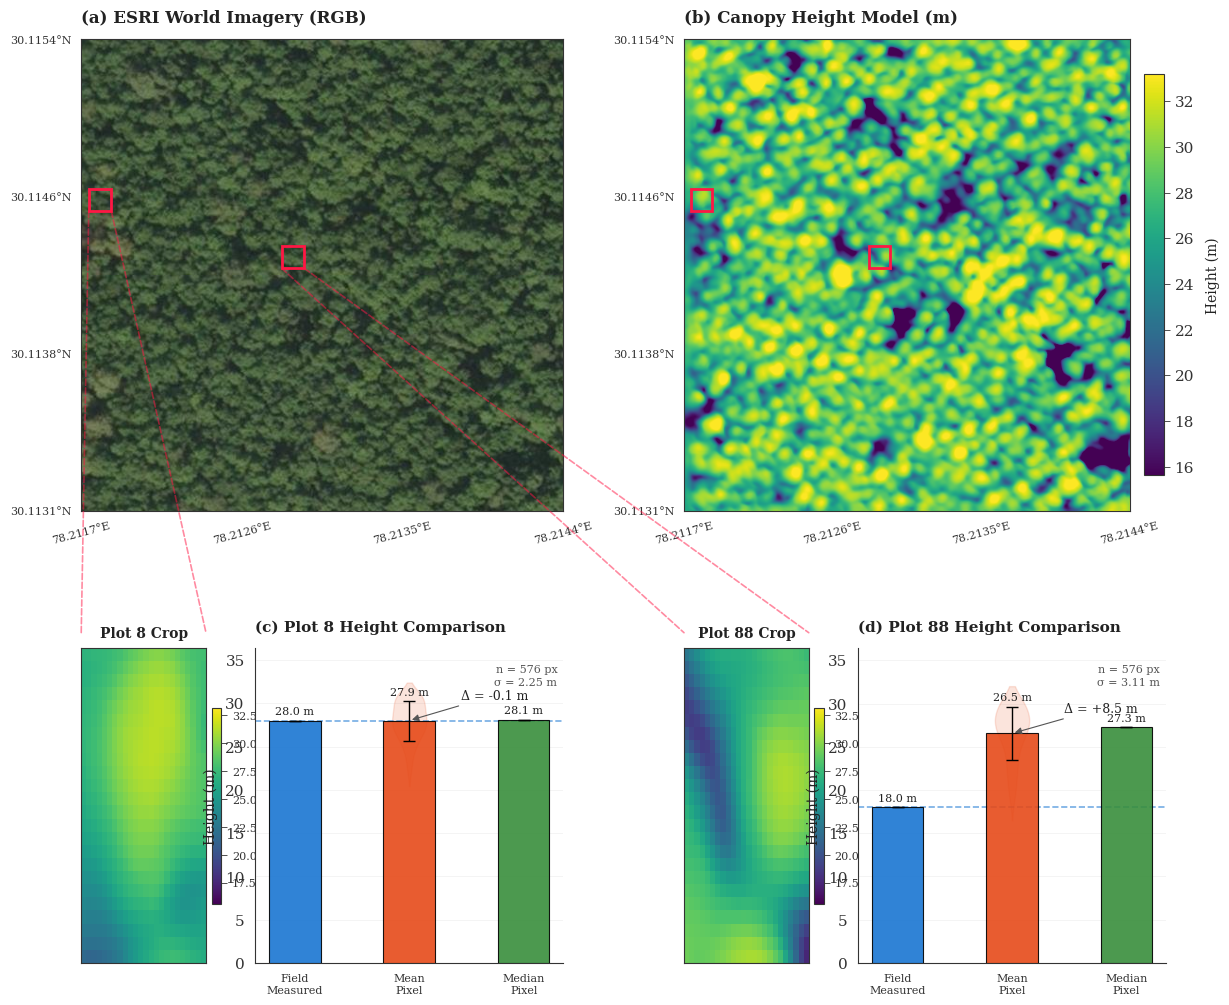

In [55]:
import json
import math
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import ConnectionPatch
import matplotlib.gridspec as mgridspec
from matplotlib.ticker import FormatStrFormatter
from scipy.stats import gaussian_kde
import numpy as np
import rasterio
from PIL import Image

# ── Paths ─────────────────────────────────────────────────────────────────────
try:
    _repo_root = repo_root
except NameError:
    _repo_root = Path.cwd().parent.parent.parent

ESRI_ROOT  = _repo_root / "data" / "input"  / "esri_patches"
CHM_ROOT   = _repo_root / "data" / "output" / "esri_results"
STATS_ROOT = _repo_root / "scripts" / "statistical_analysis" / "data"

# ── Build tile index from per-plot metadata.json ───────────────────────────────
_tile_idx = defaultdict(list)
for pdir in sorted(STATS_ROOT.iterdir()):
    mf = pdir / "metadata.json"
    if pdir.is_dir() and mf.exists():
        meta = json.loads(mf.read_text())
        if meta.get("tile_key"):
            meta["_dir"] = pdir          # stash path for pixels.npy
            _tile_idx[meta["tile_key"]].append(meta)

TARGET_TILE = None
# Find the tile with the maximum number of plots
resolved = TARGET_TILE if (TARGET_TILE and TARGET_TILE in _tile_idx) \
           else max(_tile_idx, key=lambda k: len(_tile_idx[k]))

all_tile_plots = _tile_idx[resolved]

# ONLY SELECT 2 PLOTS TO PROJECT
projected_plots = all_tile_plots[:2] 

print(f"Tile: {resolved} | Total plots in tile: {len(all_tile_plots)} | Projecting sr={[m['sr'] for m in projected_plots]}")

# ── Geo helpers ────────────────────────────────────────────────────────────────
def tile_bbox(key):
    p  = key.replace("part_0_", "").split("_")
    z, tx, ty = int(p[0][1:]), int(p[1]), int(p[2])
    n = 2 ** z
    _lon = lambda x: x / n * 360 - 180
    _lat = lambda y: math.degrees(math.atan(math.sinh(math.pi - 2 * math.pi * y / n)))
    return _lon(tx), _lat(ty + 2), _lon(tx + 2), _lat(ty)

def px_to_geo(bb, key):
    lon0, lat0, lon1, lat1 = tile_bbox(key)
    S = 512
    l = lon0 + bb["col_min"] / S * (lon1 - lon0)
    r = lon0 + bb["col_max"] / S * (lon1 - lon0)
    b = lat1 - bb["row_max"] / S * (lat1 - lat0)
    t = lat1 - bb["row_min"] / S * (lat1 - lat0)
    return l, b, r, t

lon0, lat0, lon1, lat1 = tile_bbox(resolved)
extent = [lon0, lon1, lat0, lat1]

# ── Load rasters ───────────────────────────────────────────────────────────────
with Image.open(ESRI_ROOT / f"esri_512_{resolved}.png") as _img:
    rgb = np.array(_img.convert("RGB"))

with rasterio.open(CHM_ROOT / f"esri_512_{resolved}_CHM.tif") as src:
    chm = src.read(1).astype(float)
    if src.nodata is not None:
        chm[chm == src.nodata] = np.nan

vmin_chm = np.nanpercentile(chm, 2)
vmax_chm = np.nanpercentile(chm, 98)

# ── Figure layout (Publication Grade) ──────────────────────────────────────────
plt.rcParams.update({
    "font.family"      : "serif",
    "font.size"        : 10,
    "axes.linewidth"   : 0.8,
    "axes.edgecolor"   : "#333333",
    "text.color"       : "#222222",
    "axes.labelcolor"  : "#222222",
})

n_plots = len(projected_plots)
fig = plt.figure(figsize=(7 * n_plots, 12), facecolor="white")

gs_outer = mgridspec.GridSpec(
    2, n_plots,
    figure=fig,
    height_ratios=[1.8, 1.2], 
    hspace=0.35,              
    wspace=0.25,
)

# ══ TOP ROW: mosaic panels ════════════════════════════════════════════════════
ax_rgb = fig.add_subplot(gs_outer[0, 0])
ax_chm_main = fig.add_subplot(gs_outer[0, -1])

_kw = dict(extent=extent, aspect="auto", origin="upper")

# Calculate 4 evenly spaced ticks for the borders
lon_ticks = np.linspace(lon0, lon1, 4)
lat_ticks = np.linspace(lat0, lat1, 4)

for ax, (title, data, cmap, vmin, vmax) in zip(
    [ax_rgb, ax_chm_main],
    [
        ("(a) ESRI World Imagery (RGB)", rgb, None, None, None),
        ("(b) Canopy Height Model (m)",  chm, "viridis", vmin_chm, vmax_chm),
    ],
):
    if cmap:
        im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax, **_kw)
        cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03, shrink=0.85, aspect=20)
        cb.set_label("Height (m)", fontsize=10, labelpad=8)
        cb.outline.set_linewidth(0.8)
    else:
        ax.imshow(data, **_kw)

    for meta in all_tile_plots:
        bb = meta.get("bbox")
        if bb is None:
            continue
        l, b, r, t = px_to_geo(bb, resolved)
        
        if meta in projected_plots:
            edge_color = "#FF1744" 
            line_width = 2.0
            z_order = 5
        else:
            edge_color = "#FFCDD2" 
            line_width = 1.0
            z_order = 4
            
        ax.add_patch(mpatches.Rectangle(
            (l, b), r - l, t - b,
            linewidth=line_width, edgecolor=edge_color, facecolor="none", zorder=z_order))

    # Add Coordinate Borders
    ax.set_xticks(lon_ticks)
    ax.set_yticks(lat_ticks)
    ax.xaxis.set_major_formatter(FormatStrFormatter("%.4f°E"))
    ax.yaxis.set_major_formatter(FormatStrFormatter("%.4f°N"))
    ax.tick_params(
        axis="both", which="major",
        labelsize=8, direction="out", length=4, width=0.6, pad=3,
    )
    ax.tick_params(axis="x", labelrotation=15) # Rotate to prevent overlap
    
    ax.set_title(title, fontsize=12, fontweight="bold", pad=12, loc="left")

if n_plots == 1:
    ax_chm_main.set_visible(False)

# ══ BOTTOM ROW: per-plot detail & Projections ══════════════════════════════════
BAR_COLORS = {
    "Field\nMeasured"  : "#1976D2",
    "Mean\nPixel"      : "#E64A19",
    "Median\nPixel"    : "#388E3C",
}

for col_idx, meta in enumerate(projected_plots):
    pdir = meta["_dir"]
    pixels = np.load(pdir / "pixels.npy").astype(float).ravel()

    h_field  = meta["h_avg_field"]
    h_mean   = meta["h_pred_mean"]
    h_median = meta["h_pred_median"]
    h_std    = meta["h_pred_std"]
    sr       = meta["sr"]

    gs_inner = mgridspec.GridSpecFromSubplotSpec(
        1, 2,
        subplot_spec=gs_outer[1, col_idx],
        width_ratios=[1, 2.2],
        wspace=0.15,
    )

    # ── CHM pixel crop ──────────────────────────────────────────────────────
    ax_crop = fig.add_subplot(gs_inner[0, 0])
    crop_2d = np.load(pdir / "pixels.npy").astype(float)
    im_crop = ax_crop.imshow(
        crop_2d, cmap="viridis",
        vmin=vmin_chm, vmax=vmax_chm,
        aspect="auto", origin="upper",
    )
    cb_crop = fig.colorbar(im_crop, ax=ax_crop, fraction=0.07, pad=0.04, shrink=0.85)
    cb_crop.ax.tick_params(labelsize=8)
    cb_crop.set_label("m", fontsize=8, labelpad=4)
    cb_crop.outline.set_linewidth(0.8)
    
    ax_crop.set_title(f"Plot {sr} Crop", fontsize=10, fontweight="bold", pad=8)
    ax_crop.set_xticks([]) # Keep small crop panels clean without coords
    ax_crop.set_yticks([])

    # ── Projection Lines (Frustum/Cone Zoom) ──────────────────────────────
    bb = meta.get("bbox")
    if bb is not None:
        l, b, r, t = px_to_geo(bb, resolved)
        
        # Line 1: Map Bottom-Left Corner to Crop Top-Left Corner
        con_left = ConnectionPatch(
            xyA=(l, b), coordsA=ax_rgb.transData,
            xyB=(0.0, 1.05), coordsB=ax_crop.transAxes,
            color="#FF1744", linestyle="--", linewidth=1.2, alpha=0.5
        )
        # Line 2: Map Bottom-Right Corner to Crop Top-Right Corner
        con_right = ConnectionPatch(
            xyA=(r, b), coordsA=ax_rgb.transData,
            xyB=(1.0, 1.05), coordsB=ax_crop.transAxes,
            color="#FF1744", linestyle="--", linewidth=1.2, alpha=0.5
        )
        
        fig.add_artist(con_left)
        fig.add_artist(con_right)

    # ── Bar + KDE panel ─────────────────────────────────────────────────────
    ax_bar = fig.add_subplot(gs_inner[0, 1])

    labels = list(BAR_COLORS.keys())
    values = [h_field, h_mean, h_median]
    colors = list(BAR_COLORS.values())
    errs   = [0, h_std, 0]

    x = np.arange(len(labels))
    bars = ax_bar.bar(
        x, values,
        width=0.45, 
        color=colors,
        edgecolor="black",
        linewidth=0.8,
        yerr=errs,
        error_kw=dict(elinewidth=1.0, capsize=4, capthick=1.0, ecolor="black"),
        zorder=3,
        alpha=0.9
    )

    for bar, val, err in zip(bars, values, errs):
        label = f"{val:.1f} m"
        y_pos = val + err + 0.5 if err > 0 else val + 0.5
        ax_bar.text(
            bar.get_x() + bar.get_width() / 2, y_pos, label,
            ha="center", va="bottom", fontsize=8, fontweight="500", color="#222222"
        )

    ax_bar.axhline(h_field, color="#1976D2", linestyle="--", linewidth=1.2, zorder=2, alpha=0.6)

    kde_vals = np.linspace(pixels.min() - 1, pixels.max() + 1, 300)
    kde      = gaussian_kde(pixels, bw_method=0.4)(kde_vals)
    kde_norm = kde / kde.max() * 0.15 
    ax_bar.fill_betweenx(
        kde_vals, 1 - kde_norm, 1 + kde_norm,
        color="#E64A19", alpha=0.15, zorder=1,
    )

    delta = h_mean - h_field
    sign  = "+" if delta >= 0 else ""
    y_annotation = max(h_mean, h_field) + 2.5
    ax_bar.annotate(
        f"Δ = {sign}{delta:.1f} m",
        xy=(1, max(h_mean, h_field)),
        xytext=(1.45, y_annotation),
        fontsize=9, color="#222222",
        arrowprops=dict(arrowstyle="-|>", color="#555555", lw=0.8, mutation_scale=10),
    )

    ax_bar.text(
        0.98, 0.95,
        f"n = {meta['n_pixels']} px\nσ = {h_std:.2f} m",
        transform=ax_bar.transAxes,
        ha="right", va="top", fontsize=8, color="#555555",
        linespacing=1.4
    )

    panel_letter = chr(ord("c") + col_idx)
    ax_bar.set_title(
        f"({panel_letter}) Plot {sr} Height Comparison",
        fontsize=11, fontweight="bold", pad=12, loc="left",
    )
    
    ax_bar.set_xticks(x)
    ax_bar.set_xticklabels(labels, fontsize=8) 
    ax_bar.set_ylabel("Height (m)", fontsize=10, labelpad=5)
    ax_bar.set_ylim(0, max(values) + h_std + 6.0) 
    
    ax_bar.spines["top"].set_visible(False)
    ax_bar.spines["right"].set_visible(False)
    ax_bar.yaxis.grid(True, linestyle="-", linewidth=0.5, alpha=0.3)
    ax_bar.set_axisbelow(True)

# ── Save ──────────────────────────────────────────────────────────────────────
OUT = _repo_root / "data" / "output" / f"pub_4panel_{resolved}.png"
OUT.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(OUT, dpi=300, bbox_inches="tight", facecolor="white")
print(f"Saved Publication Figure → {OUT}")
plt.show()